---
# COSC2753 | Machine Learning

## Task 3 — Member 3: Occasion and Gender Classification
---

# 1. Introduction

Task 3 trains two independent classifiers: `gender` and occasion (`usage`). Keeping them separate matches the required prediction columns, avoids a sparse Cartesian label space, and permits target-specific missing-label and imbalance handling. Both models are developed and compared in this notebook.

# 2. Library Imports and Setup

In [1]:
from copy import deepcopy
from pathlib import Path
import json, sys, time

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / 'scripts'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from skimage.feature import hog
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

from preprocessing import IMAGE_SIZE, NORMALISATION_PATH, SEED, seed_everything, select_torch_device, task_frame
seed_everything(SEED); torch.manual_seed(SEED)
DEVICE = select_torch_device()
with NORMALISATION_PATH.open(encoding='utf-8') as handle:
    normalisation = json.load(handle)
DEVICE

Using CUDA: NVIDIA GeForce RTX 3060 | PyTorch 2.11.0+cu128 | CUDA 12.8


device(type='cuda')

# 3. Shared Split and Target-Specific Filtering

In [2]:
frames = {
    target: {split: task_frame(target, split) for split in ('train', 'validation', 'test')}
    for target in ('gender', 'usage')
}
pd.DataFrame({
    (target, split): frame[target].value_counts()
    for target, split_frames in frames.items() for split, frame in split_frames.items()
}).fillna(0).astype(int)

gender                   usage                 
              train validation  test  train validation  test
Boys            529        155   130      0          0     0
Casual            0          0     0  20815       4511  4309
Ethnic            0          0     0   1786        369   415
Formal            0          0     0   1610        355   335
Girls           453         81   111      0          0     0
Home              0          0     0      1          0     0
Men           14610       3158  3144      0          0     0
NA                0          0     0     40          8    23
Party             0          0     0      9          2     2
Smart Casual      0          0     0     43          5     7
Sports            0          0     0   2729        586   625
Travel            0          0     0     17          6     2
Unisex         1453        330   297      0          0     0
Women         10006       2118  2036      0          0     0

A genuinely blank target is excluded only from that target's rows. The literal string `NA` remains a valid usage class until its meaning is confirmed. Both targets retain the same product-group split assignment.

# 4. Gender and Usage EDA

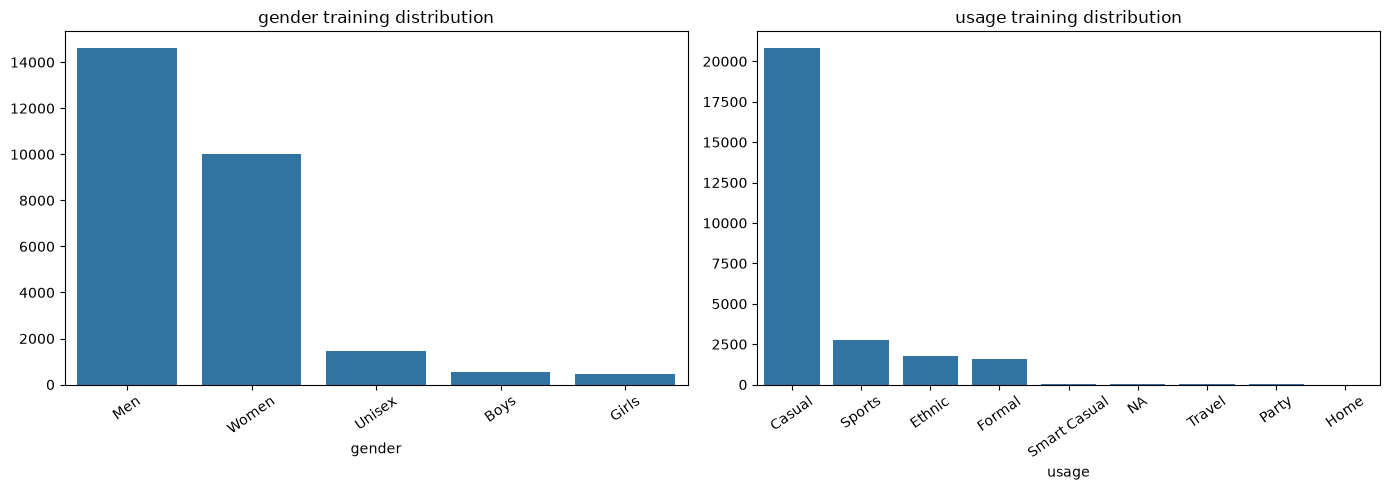

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for target, axis in zip(('gender', 'usage'), axes):
    counts = frames[target]['train'][target].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=axis)
    axis.set_title(f'{target} training distribution')
    axis.tick_params(axis='x', rotation=35)
plt.tight_layout()

In [4]:
pd.crosstab(frames['usage']['train']['articleType'], frames['usage']['train']['usage'], normalize='index').head(25).style.background_gradient(cmap='Greens')

usage,Casual,Ethnic,Formal,Home,NA,Party,Smart Casual,Sports,Travel
articleType,,,,,,,,,
Accessory Gift Set,0.200000,0.000000,0.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Baby Dolls,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
Backpacks,0.865979,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.113402,0.020619
Bangle,0.800000,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Basketballs,0.222222,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.777778,0.000000
Belts,0.819469,0.000000,0.180531,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Blazers,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Body Wash and Scrub,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Booties,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## 4.1 Observations

For gender, discuss imbalance, unisex presentation, label overlap, and article-type dependence without implying that image appearance defines a person's gender. For usage, discuss Casual dominance, rare labels, visual ambiguity, and the literal-`NA` policy.

# 5. Majority Baselines

In [5]:
baseline_rows = []
for target in ('gender', 'usage'):
    train_frame, validation_frame = frames[target]['train'], frames[target]['validation']
    dummy = DummyClassifier(strategy='most_frequent').fit(np.zeros((len(train_frame), 1)), train_frame[target])
    prediction = dummy.predict(np.zeros((len(validation_frame), 1)))
    baseline_rows.append({
        'target': target, 'accuracy': accuracy_score(validation_frame[target], prediction),
        'macro_f1': f1_score(validation_frame[target], prediction, average='macro', zero_division=0),
    })
pd.DataFrame(baseline_rows).set_index('target')

,accuracy,macro_f1
target,,
gender,0.540568,0.140356
usage,0.772167,0.108930


# 6. HOG + HSV Classical Baselines

In [6]:
feature_cache = {}
def handcrafted_feature(row):
    if row.id in feature_cache: return feature_cache[row.id]
    with Image.open(row.image_path) as source:
        image = source.convert('RGB').resize((48, 64))
    array = np.asarray(image, dtype=np.float32) / 255.0
    shape = hog(array.mean(axis=2), orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2))
    hsv = np.asarray(image.convert('HSV'), dtype=np.float32) / 255.0
    colour = np.concatenate([np.histogram(hsv[..., channel], bins=8, range=(0, 1), density=True)[0] for channel in range(3)])
    feature_cache[row.id] = np.concatenate([shape, colour]).astype(np.float32)
    return feature_cache[row.id]

classical_rows = []
for target in ('gender', 'usage'):
    train_frame, validation_frame = frames[target]['train'], frames[target]['validation']
    train_features = np.vstack([handcrafted_feature(row) for row in train_frame.itertuples()])
    validation_features = np.vstack([handcrafted_feature(row) for row in validation_frame.itertuples()])
    baseline = LogisticRegression(class_weight='balanced', max_iter=300, n_jobs=-1).fit(train_features, train_frame[target])
    prediction = baseline.predict(validation_features)
    classical_rows.append({'target': target, 'accuracy': accuracy_score(validation_frame[target], prediction), 'macro_f1': f1_score(validation_frame[target], prediction, average='macro', zero_division=0)})
pd.DataFrame(classical_rows).set_index('target')

D:\khoile\programs\fashion-intelligence-classification\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


D:\khoile\programs\fashion-intelligence-classification\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
D:\khoile\programs\fashion-intelligence-classification\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


D:\khoile\programs\fashion-intelligence-classification\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,accuracy,macro_f1
target,,
gender,0.773194,0.613422
usage,0.758302,0.397445


# 7. Shared Image Pipeline

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE[1], IMAGE_SIZE[0])), transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(8, translate=(0.05, 0.05)), transforms.ColorJitter(0.12, 0.12),
    transforms.ToTensor(), transforms.Normalize(normalisation['mean'], normalisation['std']),
])
evaluation_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE[1], IMAGE_SIZE[0])), transforms.ToTensor(),
    transforms.Normalize(normalisation['mean'], normalisation['std']),
])

class FashionDataset(Dataset):
    def __init__(self, frame, target, label_to_index, transform):
        self.frame, self.target = frame.reset_index(drop=True), target
        self.label_to_index, self.transform = label_to_index, transform
    def __len__(self): return len(self.frame)
    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(row.image_path) as image:
            tensor = self.transform(image.convert('RGB'))
        return tensor, self.label_to_index[row[self.target]]

# 8. Compact Residual CNN From Scratch

In [8]:
class ResidualBlock(nn.Module):
    def __init__(self, input_channels, output_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, output_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(output_channels)
        self.conv2 = nn.Conv2d(output_channels, output_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(output_channels)
        self.relu = nn.ReLU(inplace=True)
        self.shortcut = nn.Identity() if input_channels == output_channels and stride == 1 else nn.Sequential(
            nn.Conv2d(input_channels, output_channels, 1, stride, bias=False), nn.BatchNorm2d(output_channels),
        )
    def forward(self, inputs):
        residual = self.shortcut(inputs)
        outputs = self.relu(self.bn1(self.conv1(inputs)))
        outputs = self.bn2(self.conv2(outputs))
        return self.relu(outputs + residual)

class CompactCNN(nn.Module):
    def __init__(self, num_classes, dropout=0.2):
        super().__init__()
        self.features = nn.Sequential(
            ResidualBlock(3, 32), nn.MaxPool2d(2), ResidualBlock(32, 64), nn.MaxPool2d(2),
            ResidualBlock(64, 128), nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(dropout), nn.Linear(128, num_classes))
    def forward(self, inputs): return self.classifier(self.features(inputs))

# 9. Reusable Training Function

The function trains one independently initialized model and selects its checkpoint only by validation macro F1.

In [9]:
def train_target(target, loss_mode='weighted', epochs=40, patience_limit=7):
    train_frame, validation_frame = frames[target]['train'], frames[target]['validation']
    labels = sorted(train_frame[target].unique())
    label_to_index = {label: index for index, label in enumerate(labels)}
    train_loader = DataLoader(FashionDataset(train_frame, target, label_to_index, train_transform), 64, shuffle=True, num_workers=0)
    validation_loader = DataLoader(FashionDataset(validation_frame, target, label_to_index, evaluation_transform), 128, num_workers=0)
    model = CompactCNN(len(labels)).to(DEVICE)
    counts = train_frame[target].value_counts().reindex(labels).values
    if loss_mode == 'ordinary':
        weights = None
    elif loss_mode == 'class_balanced':
        beta = 0.9999; values = (1.0 - beta) / (1.0 - np.power(beta, counts)); values /= values.mean()
        weights = torch.tensor(values, dtype=torch.float32, device=DEVICE)
    else:
        weights = torch.tensor(len(train_frame) / (len(labels) * counts), dtype=torch.float32, device=DEVICE)
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

    def epoch(loader, training=False):
        model.train(training); losses, truth, predictions = [], [], []
        for images, targets in loader:
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            if training: optimizer.zero_grad(set_to_none=True)
            with torch.set_grad_enabled(training):
                logits = model(images); loss = criterion(logits, targets)
                if training: loss.backward(); optimizer.step()
            losses.append(loss.item() * len(targets)); truth.extend(targets.cpu().tolist()); predictions.extend(logits.argmax(1).cpu().tolist())
        return {'loss': sum(losses) / len(loader.dataset), 'accuracy': accuracy_score(truth, predictions), 'macro_f1': f1_score(truth, predictions, average='macro', zero_division=0)}

    history, best_state, best_f1, patience = [], None, -1.0, 0
    for epoch_number in range(1, epochs + 1):
        started = time.perf_counter(); train_metrics = epoch(train_loader, True); validation_metrics = epoch(validation_loader)
        history.append({'epoch': epoch_number, 'loss_mode': loss_mode, **{f'train_{k}': v for k, v in train_metrics.items()}, **{f'validation_{k}': v for k, v in validation_metrics.items()}})
        print(target, loss_mode, epoch_number, validation_metrics, f'{time.perf_counter() - started:.1f}s')
        if validation_metrics['macro_f1'] > best_f1:
            best_f1, best_state, patience = validation_metrics['macro_f1'], deepcopy(model.state_dict()), 0
        else:
            patience += 1
            if patience >= patience_limit: break
    model.load_state_dict(best_state)
    return model.cpu(), labels, label_to_index, pd.DataFrame(history), best_f1

# 10. Gender Classifier

gender weighted 1 {'loss': 1.3864744509054103, 'accuracy': 0.5641903457719959, 'macro_f1': 0.3019703336241935} 80.1s


gender weighted 2 {'loss': 1.1846189347900213, 'accuracy': 0.45515234508729885, 'macro_f1': 0.35202418167521055} 58.4s


gender weighted 3 {'loss': 1.1686747551617334, 'accuracy': 0.6042451215337213, 'macro_f1': 0.4096027867663607} 58.4s


gender weighted 4 {'loss': 1.1317993926495895, 'accuracy': 0.5071893187264636, 'macro_f1': 0.3721884359006803} 58.6s


gender weighted 5 {'loss': 1.0400409643595367, 'accuracy': 0.6271824717562479, 'macro_f1': 0.43477578641096404} 58.2s


...

gender weighted 18 {'loss': 0.8679720140287053, 'accuracy': 0.6229031153714482, 'macro_f1': 0.47536326606088686} 57.0s


gender weighted 19 {'loss': 0.8252470893061598, 'accuracy': 0.6146867511126327, 'macro_f1': 0.4789761766054064} 56.3s


gender weighted 20 {'loss': 0.7983436165750537, 'accuracy': 0.6581650119821979, 'macro_f1': 0.5320784326513313} 56.8s


gender weighted 21 {'loss': 0.8084062143818478, 'accuracy': 0.6744265662444369, 'macro_f1': 0.5028048973181425} 58.7s


gender weighted 22 {'loss': 0.8124658872476387, 'accuracy': 0.7309140705237932, 'macro_f1': 0.5350174823738625} 57.3s


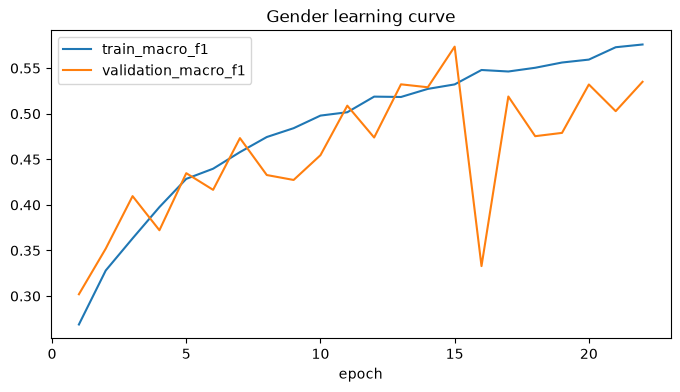

In [10]:
# Also run train_target('gender', 'ordinary') as the controlled comparison.
gender_model, gender_labels, gender_mapping, gender_history, gender_best_f1 = train_target('gender', 'weighted')
gender_history.plot(x='epoch', y=['train_macro_f1', 'validation_macro_f1'], figsize=(8, 4), title='Gender learning curve'); plt.show()

## 9.1 Gender analysis

Compare ordinary and weighted cross-entropy under identical settings. Discuss convergence, overlapping presentation, subgroup performance by article type, calibration, robustness, and responsible interpretation.

# 11. Occasion/Usage Classifier

usage class_balanced 1 {'loss': 1.7626242385421538, 'accuracy': 0.6232454638822321, 'macro_f1': 0.16905623204491033} 62.4s


usage class_balanced 2 {'loss': 1.6197721350482783, 'accuracy': 0.6610749743238616, 'macro_f1': 0.1883888143719499} 57.2s


usage class_balanced 3 {'loss': 1.7073951544968977, 'accuracy': 0.5106128038343033, 'macro_f1': 0.17564718197149368} 57.3s


usage class_balanced 4 {'loss': 1.5210475055006667, 'accuracy': 0.6573091407052379, 'macro_f1': 0.24500826927914676} 57.3s


usage class_balanced 5 {'loss': 1.4646402806788428, 'accuracy': 0.6848681958233481, 'macro_f1': 0.2614911936106297} 58.1s


...

usage class_balanced 36 {'loss': 1.436244672779676, 'accuracy': 0.6975350907223553, 'macro_f1': 0.327401371237441} 55.4s


usage class_balanced 37 {'loss': 1.373547823522565, 'accuracy': 0.7810681273536461, 'macro_f1': 0.39337056754008337} 55.6s


usage class_balanced 38 {'loss': 1.5034496819715881, 'accuracy': 0.7290311537144814, 'macro_f1': 0.3623569733681473} 55.1s


usage class_balanced 39 {'loss': 1.3769849224149344, 'accuracy': 0.5679561793906196, 'macro_f1': 0.31557716971019856} 55.9s


usage class_balanced 40 {'loss': 1.3065461268554768, 'accuracy': 0.7716535433070866, 'macro_f1': 0.369944746898669} 55.7s


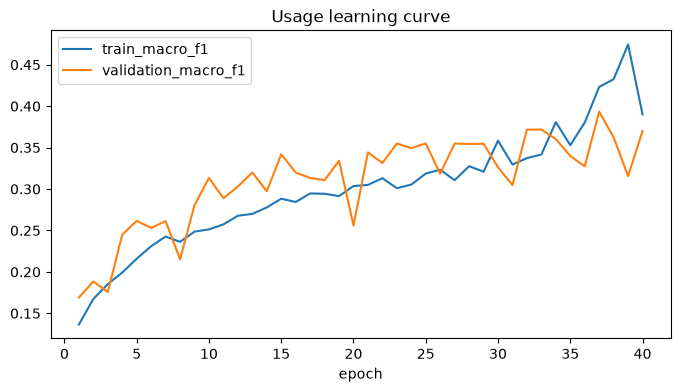

In [11]:
# Also run train_target('usage', 'ordinary') as the controlled comparison.
usage_model, usage_labels, usage_mapping, usage_history, usage_best_f1 = train_target('usage', 'class_balanced')
usage_history.plot(x='epoch', y=['train_macro_f1', 'validation_macro_f1'], figsize=(8, 4), title='Usage learning curve'); plt.show()

## 10.1 Usage analysis

Compare ordinary and weighted loss, then run a clearly labelled sensitivity analysis for literal `NA` without silently changing the final vocabulary. Discuss rare labels, Casual dominance, subjectivity, and article-type shortcuts.

# 12. One-Time Internal-Test Evaluation

In [12]:
@torch.inference_mode()
def evaluate_target(target, model, labels, label_to_index):
    loader = DataLoader(FashionDataset(frames[target]['test'], target, label_to_index, evaluation_transform), 128, num_workers=0)
    model = model.to(DEVICE).eval(); probabilities, truth = [], []
    for images, targets in loader:
        probabilities.append(model(images.to(DEVICE)).softmax(1).cpu().numpy()); truth.extend(targets.tolist())
    probabilities, truth = np.vstack(probabilities), np.asarray(truth)
    predictions = probabilities.argmax(1)
    metrics = {'accuracy': accuracy_score(truth, predictions), 'macro_f1': f1_score(truth, predictions, average='macro', zero_division=0)}
    return metrics, truth, predictions, probabilities, model.cpu()

gender_metrics, gender_truth, gender_predictions, gender_probabilities, gender_model = evaluate_target('gender', gender_model, gender_labels, gender_mapping)
usage_metrics, usage_truth, usage_predictions, usage_probabilities, usage_model = evaluate_target('usage', usage_model, usage_labels, usage_mapping)
pd.DataFrame([gender_metrics, usage_metrics], index=['gender', 'usage'])

,accuracy,macro_f1
gender,0.738895,0.577795
usage,0.770899,0.372711



GENDER
              precision    recall  f1-score   support

        Boys       0.43      0.74      0.55       130
       Girls       0.33      0.57      0.42       111
         Men       0.89      0.80      0.84      3144
      Unisex       0.22      0.67      0.33       297
       Women       0.87      0.67      0.75      2036

    accuracy                           0.74      5718
   macro avg       0.55      0.69      0.58      5718
weighted avg       0.83      0.74      0.77      5718



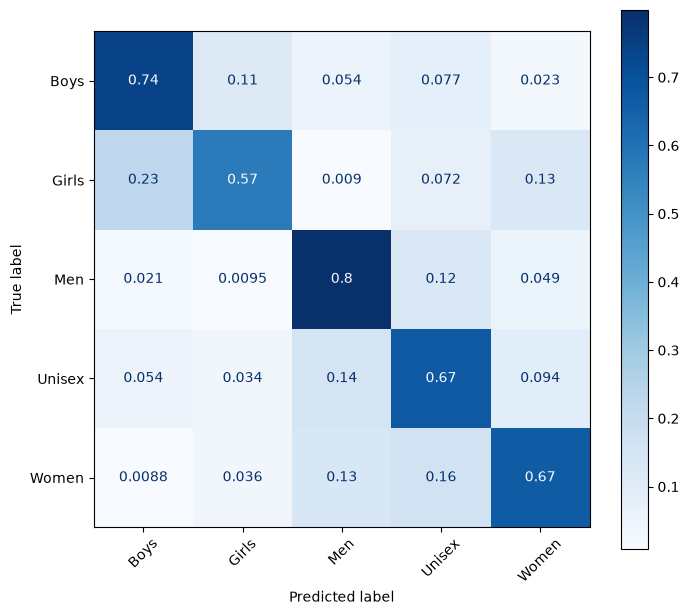


USAGE
              precision    recall  f1-score   support

      Casual       0.91      0.79      0.85      4309
      Ethnic       0.77      0.85      0.81       415
      Formal       0.38      0.86      0.53       335
        Home       0.00      0.00      0.00         0
          NA       0.17      0.09      0.11        23
       Party       0.04      0.50      0.08         2
Smart Casual       0.02      0.29      0.03         7
      Sports       0.61      0.55      0.58       625
      Travel       0.00      0.00      0.00         2

    accuracy                           0.77      5718
   macro avg       0.32      0.44      0.33      5718
weighted avg       0.83      0.77      0.79      5718



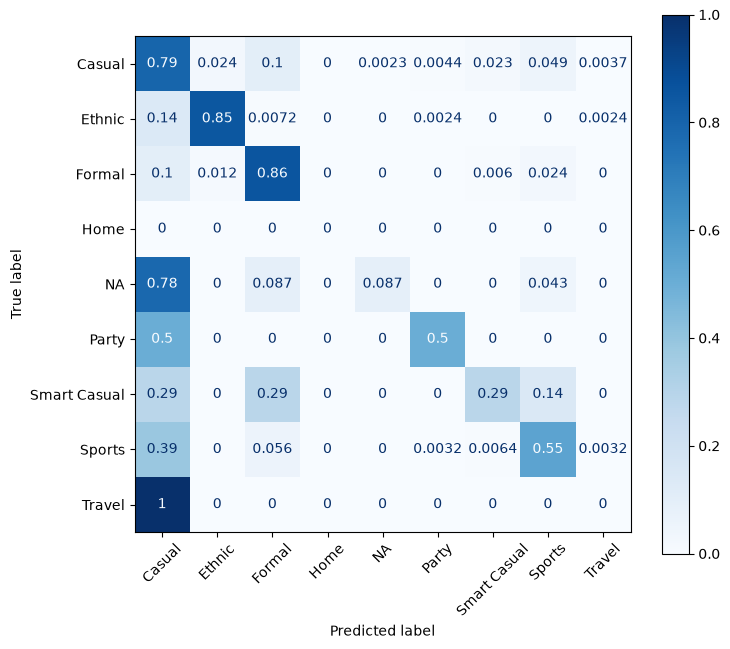

In [13]:
for target, truth, predictions, labels in [
    ('gender', gender_truth, gender_predictions, gender_labels),
    ('usage', usage_truth, usage_predictions, usage_labels),
]:
    print(f'\n{target.upper()}')
    label_indices = np.arange(len(labels))
    print(classification_report(
        truth, predictions, labels=label_indices, target_names=labels, zero_division=0,
    ))
    fig, ax = plt.subplots(figsize=(8, 7))
    ConfusionMatrixDisplay.from_predictions(
        truth, predictions, labels=label_indices, display_labels=labels, normalize='true',
        ax=ax, cmap='Blues', xticks_rotation=45,
    )
    plt.show()

## 11.1 Comparative failure analysis

Compare the two targets without averaging them into one score. Include high-confidence errors, article-type subgroups, per-class support, calibration, mild corruption robustness, latency, model size, and qualitative ambiguity.

# 13. Save Both Selected Models

In [14]:
def save_classifier(target, model, labels, best_f1, test_metrics):
    path = ROOT / 'models' / f'{target}_model.pt'
    torch.save({
        'target': target, 'labels': labels, 'state_dict': model.state_dict(),
        'mean': normalisation['mean'], 'std': normalisation['std'], 'image_size': list(IMAGE_SIZE),
        'dropout': 0.2, 'selection_metric': 'validation_macro_f1',
        'best_validation_macro_f1': best_f1, 'test_metrics': test_metrics, 'seed': SEED,
    }, path)
    return path

gender_path = save_classifier('gender', gender_model, gender_labels, gender_best_f1, gender_metrics)
usage_path = save_classifier('usage', usage_model, usage_labels, usage_best_f1, usage_metrics)
gender_history.to_csv(ROOT / 'models' / 'gender_history.csv', index=False)
usage_history.to_csv(ROOT / 'models' / 'usage_history.csv', index=False)
gender_path, usage_path

(WindowsPath('D:/khoile/programs/fashion-intelligence-classification/models/gender_model.pt'),
 WindowsPath('D:/khoile/programs/fashion-intelligence-classification/models/usage_model.pt'))

# 14. Final Prediction and Submission

Verify a single target with `python scripts/task3_occasion_gender_classification.py --image path/to/image.jpg --target gender`. After Tasks 1 and 2 deliver their checkpoints, generate all four prediction columns with `python scripts/task3_occasion_gender_classification.py --submission`.

# 15. Ultimate Judgement and Conclusion

Replace this prompt with separate comparisons among majority, HOG+HSV, ordinary-loss residual CNN, and weighted residual CNN for both targets; include the final literal-`NA` policy, major limitations, and confirmation that both checkpoints satisfy the shared inference contract.